In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score

In [2]:
data = pd.read_excel("/content/Customer_feedback (1).xlsx")
print(data.head())

                                          Feedback           Category
0            Wrong color received and I need help.            Product
1        Gift wrapping available for order #82633.    General Inquiry
2   Checkout page not loading for my recent order.  Technical Support
3        Package not received on my first attempt.           Delivery
4  Password reset not working as soon as possible.  Technical Support


In [3]:
print(data.shape)
print(data.info())
print(data["Category"].value_counts())

(1060, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Feedback  1060 non-null   object
 1   Category  1060 non-null   object
dtypes: object(2)
memory usage: 16.7+ KB
None
Category
Product              212
General Inquiry      212
Technical Support    212
Delivery             212
Billing              212
Name: count, dtype: int64


In [4]:
print("Before removing duplicates:", data.shape)

data = data.drop_duplicates()

print("After removing duplicates:", data.shape)

Before removing duplicates: (1060, 2)
After removing duplicates: (556, 2)


In [5]:
X = data["Feedback"]
y = data["Category"]

In [6]:
print(data.columns)
print(data["Category"].value_counts())
print(data.duplicated().sum())

Index(['Feedback', 'Category'], dtype='object')
Category
Billing              118
General Inquiry      113
Technical Support    110
Delivery             110
Product              105
Name: count, dtype: int64
0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
model = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("classifier", MultinomialNB())
])

In [11]:
model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()),
                ('classifier', MultinomialNB())])

In [12]:
y_pred = model.predict(X_test)

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9642857142857143


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                   precision    recall  f1-score   support

          Billing       0.96      1.00      0.98        24
         Delivery       0.95      0.86      0.90        22
  General Inquiry       1.00      1.00      1.00        23
          Product       0.91      1.00      0.95        21
Technical Support       1.00      0.95      0.98        22

         accuracy                           0.96       112
        macro avg       0.96      0.96      0.96       112
     weighted avg       0.97      0.96      0.96       112



In [16]:
feedback = ["Something is not working properly"]

prediction = model.predict(feedback)

print(prediction[0])

Technical Support


In [17]:
feedback = input("Enter customer feedback: ")

prediction = model.predict([feedback])[0]

department = {
    "Billing": "Finance Team",
    "Delivery": "Logistics Team",
    "Product": "Quality Assurance Team",
    "Technical Support": "IT Support Team",
    "General Inquiry": "Customer Care Team"
}

print("\nPredicted Category :", prediction)
print("Route To :", department[prediction])

Enter customer feedback: I would like to know more about my order

Predicted Category : General Inquiry
Route To : Customer Care Team


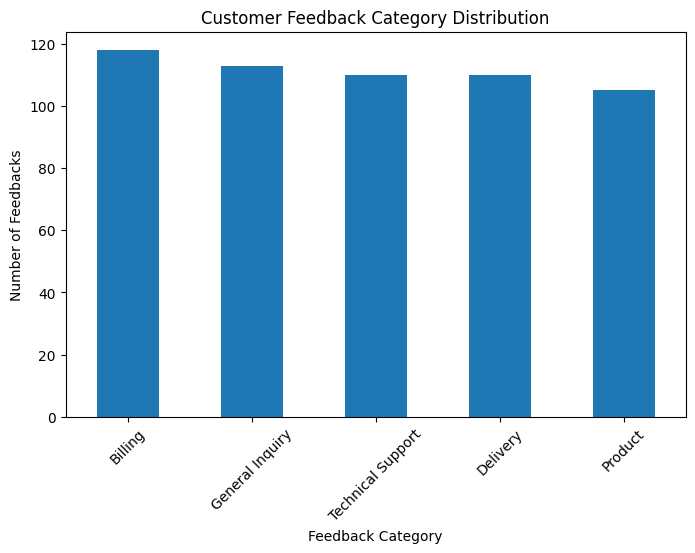

In [19]:
import matplotlib.pyplot as plt

category_counts = data["Category"].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind="bar")

plt.xlabel("Feedback Category")
plt.ylabel("Number of Feedbacks")
plt.title("Customer Feedback Category Distribution")

plt.xticks(rotation=45)
plt.show()